# Test fuzzy c-means 1 tanpa svd

In [ ]:
from google.colab import files

# Upload file  dari komputer
upload_file = files.upload()

Saving teks beneran bersih rill cuy.csv to teks beneran bersih rill cuy (1).csv


In [ ]:
import pandas as pd

# Membaca file CSV
file_name = 'teks beneran bersih rill cuy.csv'
df = pd.read_csv(file_name)

df.head()

,judul,tanggal,isi,kategori,cleaned_text,norm_text,token_text,swremove_text,clean_text,kategori_encoded
0,Badan Kurus Tak Berarti Bebas dari Kolesterol ...,"Kamis, 05 Sep 2024 11:03 WIB",Jakarta - Tak sedikit yang beranggapan bahwa o...,Kesehatan,Jakarta Tak sedikit yang beranggapan bahwa ora...,jakarta tidak sedikit yang beranggapan bahwa o...,"['jakarta', 'tidak', 'sedikit', 'yang', 'beran...","['jakarta', 'sedikit', 'beranggapan', 'orang',...",jakarta sedikit beranggapan orang berbadan kur...,0
1,Budaya Kerja Toksik di Jepang Picu 54 Karyawan...,"Kamis, 05 Sep 2024 10:38 WIB",Jakarta -\n \n Istilah 'bekerja ...,Kesehatan,Jakarta Istilah bekerja sampai mati nampaknya ...,jakarta istilah bekerja sampai mati nampaknya ...,"['jakarta', 'istilah', 'bekerja', 'sampai', 'm...","['jakarta', 'istilah', 'bekerja', 'mati', 'nam...",jakarta istilah bekerja mati nampaknya ssudah ...,0
2,Menyoal Serangan Jantung yang Dialami Faisal B...,"Kamis, 05 Sep 2024 10:03 WIB",Jakarta - Faisal Basri meninggal dunia. Ekonom...,Kesehatan,Jakarta Faisal Basri meninggal dunia Ekonom Un...,jakarta faisal basri meninggal dunia ekonom un...,"['jakarta', 'faisal', 'basri', 'meninggal', 'd...","['jakarta', 'faisal', 'basri', 'meninggal', 'd...",jakarta faisal basri meninggal dunia ekonom un...,0
3,Nyeri Kronis yang Bikin Paus Fransiskus Tak Bi...,"Kamis, 05 Sep 2024 09:37 WIB",Jakarta - Pemimpin tertinggi Gereja Katolik se...,Kesehatan,Jakarta Pemimpin tertinggi Gereja Katolik sedu...,jakarta pemimpin tertinggi gereja katolik sedu...,"['jakarta', 'pemimpin', 'tertinggi', 'gereja',...","['jakarta', 'pemimpin', 'tertinggi', 'gereja',...",jakarta pemimpin tertinggi gereja katolik sedu...,0
4,"Perundungan PPDS Tak Cuma Terjadi di Undip, Be...","Kamis, 05 Sep 2024 08:35 WIB",Jakarta - Aksi bullying atau perundungan di ma...,Kesehatan,Jakarta Aksi bullying atau perundungan di masa...,jakarta aksi bullying atau perundungan di masa...,"['jakarta', 'aksi', 'bullying', 'atau', 'perun...","['jakarta', 'aksi', 'bullying', 'perundungan',...",jakarta aksi bullying perundungan masa program...,0


In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.7 MB/s eta 0:00:00


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Extract the `clean_text` column
clean_texts = df['clean_text'].dropna()

# Convert text data into TF-IDF features
tfidf_vectorizer = TfidfVectorizer(max_features=500)  # Limit to top 500 features for efficiency
tfidf_matrix = tfidf_vectorizer.fit_transform(clean_texts)

tfidf_matrix.shape  # Show the shape of the resulting matrix

(100, 500)

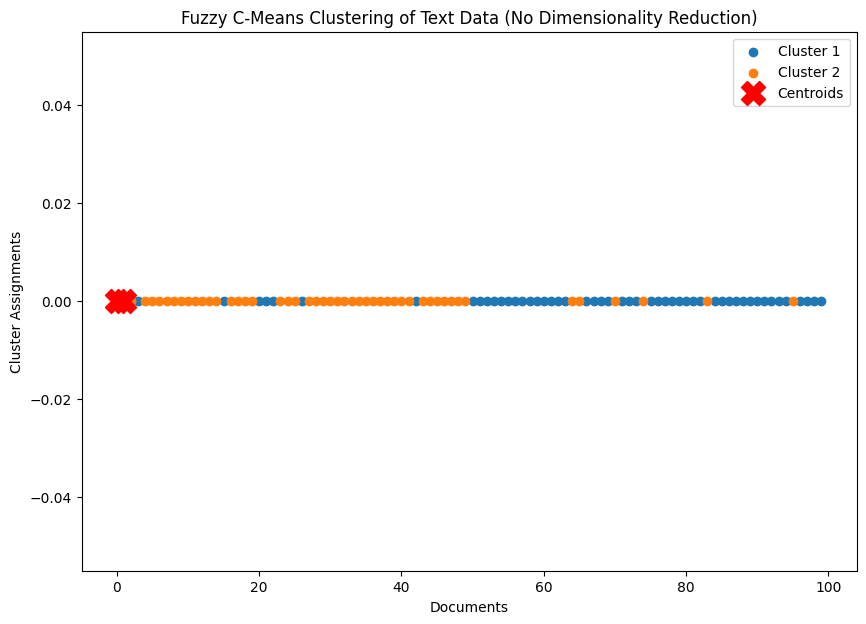

In [ ]:
import numpy as np
from fcmeans import FCM
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Initialize Fuzzy C-Means with a reasonable number of clusters (e.g., 2)
n_clusters = 2
fcm = FCM(n_clusters=n_clusters, random_state=11)

# Fit Fuzzy C-Means on the original TF-IDF matrix (without dimensionality reduction)
fcm.fit(tfidf_matrix.toarray())  # Assuming tfidf_matrix is already computed

# Get the fuzzy membership and cluster centers
membership = fcm.u
cluster_centers = fcm.centers

# Find the cluster with the highest membership for each document
cluster_labels = np.argmax(membership, axis=1)

# Plot the results using the first two features of the TF-IDF matrix (for visualization)
plt.figure(figsize=(10, 7))

# Visualize the clustering
for i in range(n_clusters):
    plt.scatter(np.arange(len(cluster_labels))[cluster_labels == i],
                np.zeros_like(np.arange(len(cluster_labels)))[cluster_labels == i], label=f'Cluster {i+1}')

# Plot centroids
plt.scatter(np.arange(n_clusters), np.zeros(n_clusters), s=300, c='red', marker='X', label='Centroids')

plt.title('Fuzzy C-Means Clustering of Text Data (No Dimensionality Reduction)')
plt.xlabel('Documents')
plt.ylabel('Cluster Assignments')
plt.legend()
plt.show()

In [ ]:
# Output the number of members in each cluster
cluster_counts = np.bincount(cluster_labels)
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count} anggota")

Cluster 0: 52 anggota
Cluster 1: 48 anggota


# Test fuzzy c-means 2 dengan svd

In [ ]:
from google.colab import files

# Upload file  dari komputer
upload_file = files.upload()

Saving teks beneran bersih rill cuy.csv to teks beneran bersih rill cuy.csv


In [ ]:
import pandas as pd

# Membaca file CSV
file_name = 'teks beneran bersih rill cuy.csv'
df = pd.read_csv(file_name)

df.head()

,judul,tanggal,isi,kategori,cleaned_text,norm_text,token_text,swremove_text,clean_text,kategori_encoded
0,Badan Kurus Tak Berarti Bebas dari Kolesterol ...,"Kamis, 05 Sep 2024 11:03 WIB",Jakarta - Tak sedikit yang beranggapan bahwa o...,Kesehatan,Jakarta Tak sedikit yang beranggapan bahwa ora...,jakarta tidak sedikit yang beranggapan bahwa o...,"['jakarta', 'tidak', 'sedikit', 'yang', 'beran...","['jakarta', 'sedikit', 'beranggapan', 'orang',...",jakarta sedikit beranggapan orang berbadan kur...,0
1,Budaya Kerja Toksik di Jepang Picu 54 Karyawan...,"Kamis, 05 Sep 2024 10:38 WIB",Jakarta -\n \n Istilah 'bekerja ...,Kesehatan,Jakarta Istilah bekerja sampai mati nampaknya ...,jakarta istilah bekerja sampai mati nampaknya ...,"['jakarta', 'istilah', 'bekerja', 'sampai', 'm...","['jakarta', 'istilah', 'bekerja', 'mati', 'nam...",jakarta istilah bekerja mati nampaknya ssudah ...,0
2,Menyoal Serangan Jantung yang Dialami Faisal B...,"Kamis, 05 Sep 2024 10:03 WIB",Jakarta - Faisal Basri meninggal dunia. Ekonom...,Kesehatan,Jakarta Faisal Basri meninggal dunia Ekonom Un...,jakarta faisal basri meninggal dunia ekonom un...,"['jakarta', 'faisal', 'basri', 'meninggal', 'd...","['jakarta', 'faisal', 'basri', 'meninggal', 'd...",jakarta faisal basri meninggal dunia ekonom un...,0
3,Nyeri Kronis yang Bikin Paus Fransiskus Tak Bi...,"Kamis, 05 Sep 2024 09:37 WIB",Jakarta - Pemimpin tertinggi Gereja Katolik se...,Kesehatan,Jakarta Pemimpin tertinggi Gereja Katolik sedu...,jakarta pemimpin tertinggi gereja katolik sedu...,"['jakarta', 'pemimpin', 'tertinggi', 'gereja',...","['jakarta', 'pemimpin', 'tertinggi', 'gereja',...",jakarta pemimpin tertinggi gereja katolik sedu...,0
4,"Perundungan PPDS Tak Cuma Terjadi di Undip, Be...","Kamis, 05 Sep 2024 08:35 WIB",Jakarta - Aksi bullying atau perundungan di ma...,Kesehatan,Jakarta Aksi bullying atau perundungan di masa...,jakarta aksi bullying atau perundungan di masa...,"['jakarta', 'aksi', 'bullying', 'atau', 'perun...","['jakarta', 'aksi', 'bullying', 'perundungan',...",jakarta aksi bullying perundungan masa program...,0


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Extract the `clean_text` column
clean_texts = df['clean_text'].dropna()

# Convert text data into TF-IDF features
tfidf_vectorizer = TfidfVectorizer(max_features=500)  # Limit to top 500 features for efficiency
tfidf_matrix = tfidf_vectorizer.fit_transform(clean_texts)

# Mengonversi matriks TF-IDF ke dalam DataFrame untuk memudahkan visualisasi
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Menampilkan DataFrame TF-IDF
print(tfidf_df.head(100))

       acara       ada    adalah  adanya  advertisement  agung   agustus  \
0   0.000000  0.000000  0.000000     0.0       0.016420    0.0  0.000000   
1   0.000000  0.022256  0.000000     0.0       0.012762    0.0  0.000000   
2   0.000000  0.000000  0.000000     0.0       0.010738    0.0  0.000000   
3   0.069173  0.072833  0.000000     0.0       0.020882    0.0  0.000000   
4   0.000000  0.020832  0.000000     0.0       0.011946    0.0  0.035551   
..       ...       ...       ...     ...            ...    ...       ...   
95  0.000000  0.000000  0.000000     0.0       0.054988    0.0  0.000000   
96  0.000000  0.000000  0.000000     0.0       0.058777    0.0  0.000000   
97  0.000000  0.062269  0.000000     0.0       0.035707    0.0  0.000000   
98  0.102326  0.026935  0.042085     0.0       0.030891    0.0  0.000000   
99  0.000000  0.000000  0.000000     0.0       0.003662    0.0  0.000000   

    ahli       air  airbus  ...     viral     waktu    wanita     warga  who  \
0    0.

In [ ]:
from sklearn.preprocessing import normalize

# Normalisasi matriks TF-IDF
normalized_tfidf_matrix = normalize(tfidf_matrix, norm='l2', axis=1)

# Tampilkan ukuran matriks hasil normalisasi
print(f"Shape of normalized TF-IDF matrix: {normalized_tfidf_matrix.shape}")

Shape of normalized TF-IDF matrix: (100, 500)


In [ ]:
! pip install fuzzy-c-means

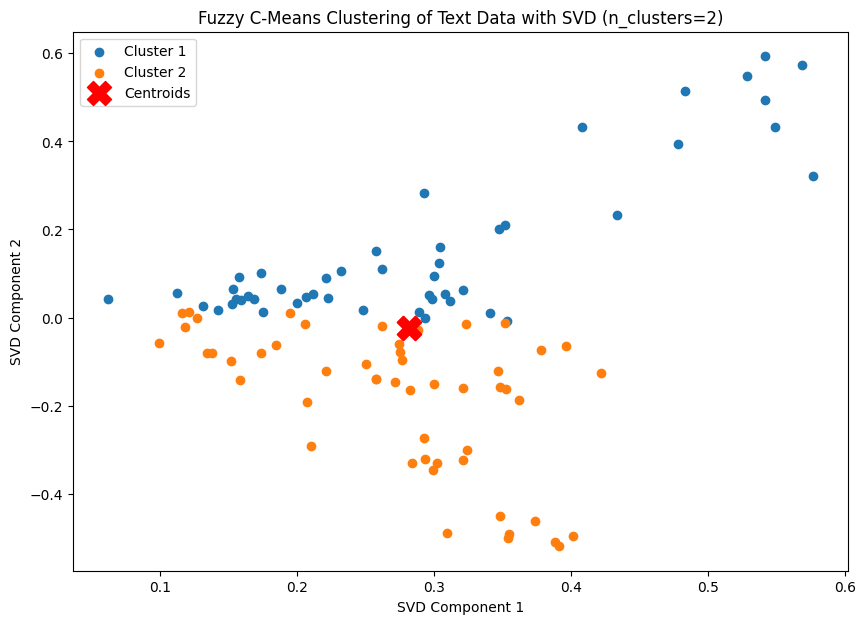

In [ ]:
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

# Reduksi dimensi menggunakan SVD (untuk efisiensi visualisasi)
svd_asli = TruncatedSVD(n_components=499)
reduced_data_asli = svd_asli.fit_transform(normalized_tfidf_matrix)
svd = TruncatedSVD(n_components=2)
reduced_data = svd.fit_transform(normalized_tfidf_matrix)
# Cobalah jumlah cluster yang berbeda untuk mendapatkan hasil terbaik
n_clusters = 2  # Bisa diubah sesuai eksperimen
fcm = FCM(n_clusters=n_clusters, random_state=11, m=1.5, max_iter=200, epsilon=1e-5)
fcm.fit(reduced_data_asli)

# Dapatkan fuzzy membership dan pusat cluster
membership = fcm.u
cluster_centers = fcm.centers

# Visualisasi hasil clustering
plt.figure(figsize=(10, 7))

# Menentukan cluster dengan membership tertinggi untuk setiap dokumen
cluster_labels = np.argmax(membership, axis=1)

# Plot titik data dalam ruang 2D yang sudah direduksi, dengan warna berdasarkan cluster
for i in range(n_clusters):
    plt.scatter(reduced_data[cluster_labels == i, 0],
                reduced_data[cluster_labels == i, 1], label=f'Cluster {i+1}')

# Plot centroid
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title(f'Fuzzy C-Means Clustering of Text Data with SVD (n_clusters={n_clusters})')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.legend()
plt.show()

In [ ]:
# Hitung jumlah anggota di setiap cluster
cluster_counts = np.bincount(cluster_labels)

# Tampilkan hasil
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count} anggota")

Cluster 0: 48 anggota
Cluster 1: 52 anggota


In [ ]:
# Pisahkan data berdasarkan hasil clustering
cluster_0 = results_sorted[results_sorted["Hasil Clustering"] == 0].reset_index(drop=True)
cluster_1 = results_sorted[results_sorted["Hasil Clustering"] == 1].reset_index(drop=True)

# Gabungkan kedua cluster secara horizontal
merged_results = pd.concat([cluster_0, cluster_1], axis=1)

# Tampilkan hasil
print("Tabel Hasil Clustering (Cluster 0 di kiri, Cluster 1 di kanan):")
print(merged_results.to_string(index=False))

# Opsional: Simpan ke file CSV
merged_results.to_csv("merged_clustering_results.csv", index=False)

Tabel Hasil Clustering (Cluster 0 di kiri, Cluster 1 di kanan):
 ID Berita  Hasil Clustering  Label  ID Berita  Hasil Clustering  Label
        99                 0      1       65.0               1.0    1.0
        76                 0      1       83.0               1.0    1.0
        75                 0      1       70.0               1.0    1.0
        73                 0      1       95.0               1.0    1.0
        72                 0      1       74.0               1.0    1.0
        71                 0      1       64.0               1.0    1.0
        69                 0      1        0.0               1.0    0.0
        68                 0      1       47.0               1.0    0.0
        67                 0      1       23.0               1.0    0.0
        66                 0      1       19.0               1.0    0.0
        42                 0      0       18.0               1.0    0.0
        63                 0      1       17.0               1.0    0.0


In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

# Mengonversi keanggotaan fuzzy menjadi label cluster dengan memilih cluster dengan membership tertinggi
fuzzy_labels = np.argmax(membership, axis=1)

# Menghitung Silhouette Score
silhouette_avg = silhouette_score(normalized_tfidf_matrix, fuzzy_labels)

# Menampilkan Silhouette Score
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.0328
